# Supplementary Figures S4–S5: non-spatial model analyses

Calculate the S4b velocity field directly from the three fitted LR models.
Convert the measured cells, explicit trajectory outputs, directed interaction
tables and evaluation results into the numerical inputs for S4–S5, then draw
the figures from that new directory.

S4b uses the LR-informed training seeds 42, 43 and 44, each averaged over five
16-cell groupings; S4c/d compare the radius-graph Full and No-interaction models.
S5 uses the corresponding cortical Full model.

Run these cells with the CytoBridge code folder available. The downloads
provide the prepared data, trained models and numerical analysis outputs.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

import CytoBridge as cb
from IPython.display import Image, display

project = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")).resolve()
device = os.environ.get("CYTOBRIDGE_DEVICE", "cuda")
run_name = os.environ.get("CYTOBRIDGE_RUN_LABEL", "reader_run")
repo = Path(cb.__file__).resolve().parents[1]

def run(module, *arguments):
    subprocess.run([sys.executable, "-m", module, *map(str, arguments)],
                   cwd=repo, check=True)

import json
from reproduction.nonspatial.inputs import downloaded_sources

source_override = os.environ.get("CYTOBRIDGE_NONSPATIAL_SOURCES")
if source_override:
    selected = json.loads(Path(source_override).read_text())
    weinreb, scnt = selected["weinreb"], selected["scnt"]
    field_models = selected["weinreb_field_models"]
else:
    for dataset in ("weinreb", "scnt_cortex"):
        if not (project / "data" / dataset / "full/model/config.yaml").is_file():
            cb.datasets.download(dataset, destination=project)
    paper = project / "data/nonspatial/paper"
    if not (paper / "weinreb/lr_seed44/model/config.yaml").is_file():
        cb.datasets.download("nonspatial", destination=project,
                             kind="nonspatial_paper_inputs.zip")
    weinreb, scnt, field_models = downloaded_sources(project)

output = project / "outputs" / ("nonspatial_" + run_name)
output.mkdir(parents=True, exist_ok=False)

## S4b. Evaluate and smooth the fitted velocity field

Evaluate intrinsic drift and the score gradient on every measured 50-PC
state. Evaluate interactions for grouping seeds 0–4, average those fields
within each model, then average the three models. Smooth PC1–PC2 values on
the original 50×50 grid, retaining only the data-supported region.

In [2]:
from reproduction.nonspatial.fields import calculate_weinreb_fields
weinreb["model_grids"] = calculate_weinreb_fields(
    weinreb["prepared_h5ad"], field_models, output / "weinreb_model_fields",
    device=device, grouping_seeds=(0, 1, 2, 3, 4))
weinreb["model_grids"]

PosixPath('/data/cytobridge/projects/CytoBridge-ST-1104/runs/package-reader-repair-20260907/simulation_nonspatial/notebook_project/outputs/nonspatial_full_reader_r1/weinreb_model_fields/support_masked_stream_grids.npz')

## Select the numerical results for the other panels

The source dictionaries below identify each input file. Distribution and
clone-fate tables are recorded evaluations of the selected fitted models.
The S5 dense trajectory records the Full model's simulated 50-PC states;
its streamlines are calculated here by finite differences, not read as a plot.
The directed GNN-message and LR-attribution tables are model-analysis outputs.
CellChat scores are an independent reference. This cell does not rerun those
upstream evaluations.

To use newly calculated results, replace the corresponding dictionary path
with your evaluation's output before continuing. Source filenames and producer
descriptions are listed in `reproduction/nonspatial/source_keys.json`.

In [3]:
display(weinreb)
display(scnt)

{'prepared_h5ad': '/data/cytobridge/projects/CytoBridge-ST-1104/runs/weinreb-gnn-review/20260718/data/Weinreb_prepared_50pc.h5ad',
 'distribution': '/data/cytobridge/projects/CytoBridge-ST-1104/runs/nonspatial-corrected-matched-e80c18a-20260815-r1/weinreb/frozen_full_vs_corrected_no_interaction/distribution/paired_weighted_distribution_metrics.csv',
 'clone_fate': '/data/cytobridge/projects/CytoBridge-ST-1104/runs/nonspatial-corrected-matched-e80c18a-20260815-r1/weinreb/frozen_full_vs_corrected_no_interaction/clone_fate/frozen_full_vs_corrected_no_interaction_summary.csv',
 'cellchat_joined': '/data/cytobridge/projects/CytoBridge-ST-1104/runs/weinreb-ccc-multimethod/20260722/figure_weinreb_nonspatial_interaction_20260810/panel_data/cellchat_joined_directed_edges.csv',
 'pathways': '/data/cytobridge/projects/CytoBridge-ST-1104/runs/weinreb-ccc-multimethod/20260722/figure_weinreb_nonspatial_interaction_20260810/panel_data/cytobridge_pathway_scores.csv',
 'model_grids': PosixPath('/data/c

{'prepared_h5ad': '/data/cytobridge/projects/CytoBridge-ST-1104/runs/neuron-full-cortex/20260811/processed/hvg2000/scnt_cortical_full_hvg2000_latent.h5ad',
 'full_trajectory': '/data/cytobridge/projects/CytoBridge-ST-1104/runs/neuron-full-cortex/20260811/reviews/figure_scnt_nonspatial_interaction_a4_20260815/panel_data/full_paired_dense_trajectory.npz',
 'full_distribution': '/data/cytobridge/projects/CytoBridge-ST-1104/runs/neuron-full-cortex/20260811/reviews/figure_scnt_nonspatial_interaction_a4_20260815/panel_data/full_distribution_metrics.csv',
 'no_interaction_distribution': '/data/cytobridge/projects/CytoBridge-ST-1104/runs/nonspatial-corrected-matched-e80c18a-20260815-r1/scnt_cortex/frozen_full_vs_corrected_no_interaction/distribution/no_interaction_noise/distribution_metrics.csv',
 'direction': '/data/cytobridge/projects/CytoBridge-ST-1104/runs/nonspatial-corrected-matched-e80c18a-20260815-r1/scnt_cortex/frozen_full_vs_corrected_no_interaction/scnt_direction/timewise_scnt_direc

## Calculate all displayed arrays and tables

Read measured labels and coordinates from H5AD. Calculate cell counts,
distribution changes, clone/direction summaries, trajectory streamlines,
receiver interaction vectors, the displayed network edges and pathway ranks.
Recalculate the CellChat correlations from all eligible directed type pairs
(100/121/121 for Weinreb days 2/4/6; 81 for the final cortical time point).
The existing paper plotting functions keep their original axes and style.

In [4]:
from reproduction.nonspatial.inputs import collect_nonspatial_inputs
from CytoBridge.results import calculate_nonspatial_panels, write_nonspatial_tables

data = collect_nonspatial_inputs(weinreb, scnt, output / "plot_inputs")
panels = calculate_nonspatial_panels(data)
tables = write_nonspatial_tables(panels, output / "figures")
tables

{'weinreb_distribution': PosixPath('/data/cytobridge/projects/CytoBridge-ST-1104/runs/package-reader-repair-20260907/simulation_nonspatial/notebook_project/outputs/nonspatial_full_reader_r1/figures/weinreb_distribution.csv'),
 'weinreb_clone_fate': PosixPath('/data/cytobridge/projects/CytoBridge-ST-1104/runs/package-reader-repair-20260907/simulation_nonspatial/notebook_project/outputs/nonspatial_full_reader_r1/figures/weinreb_clone_fate.csv'),
 'weinreb_concordance': PosixPath('/data/cytobridge/projects/CytoBridge-ST-1104/runs/package-reader-repair-20260907/simulation_nonspatial/notebook_project/outputs/nonspatial_full_reader_r1/figures/weinreb_concordance.csv'),
 'weinreb_pathways': PosixPath('/data/cytobridge/projects/CytoBridge-ST-1104/runs/package-reader-repair-20260907/simulation_nonspatial/notebook_project/outputs/nonspatial_full_reader_r1/figures/weinreb_pathways.csv'),
 'scnt_distribution': PosixPath('/data/cytobridge/projects/CytoBridge-ST-1104/runs/package-reader-repair-20260

## Draw S4–S5 from the new inputs

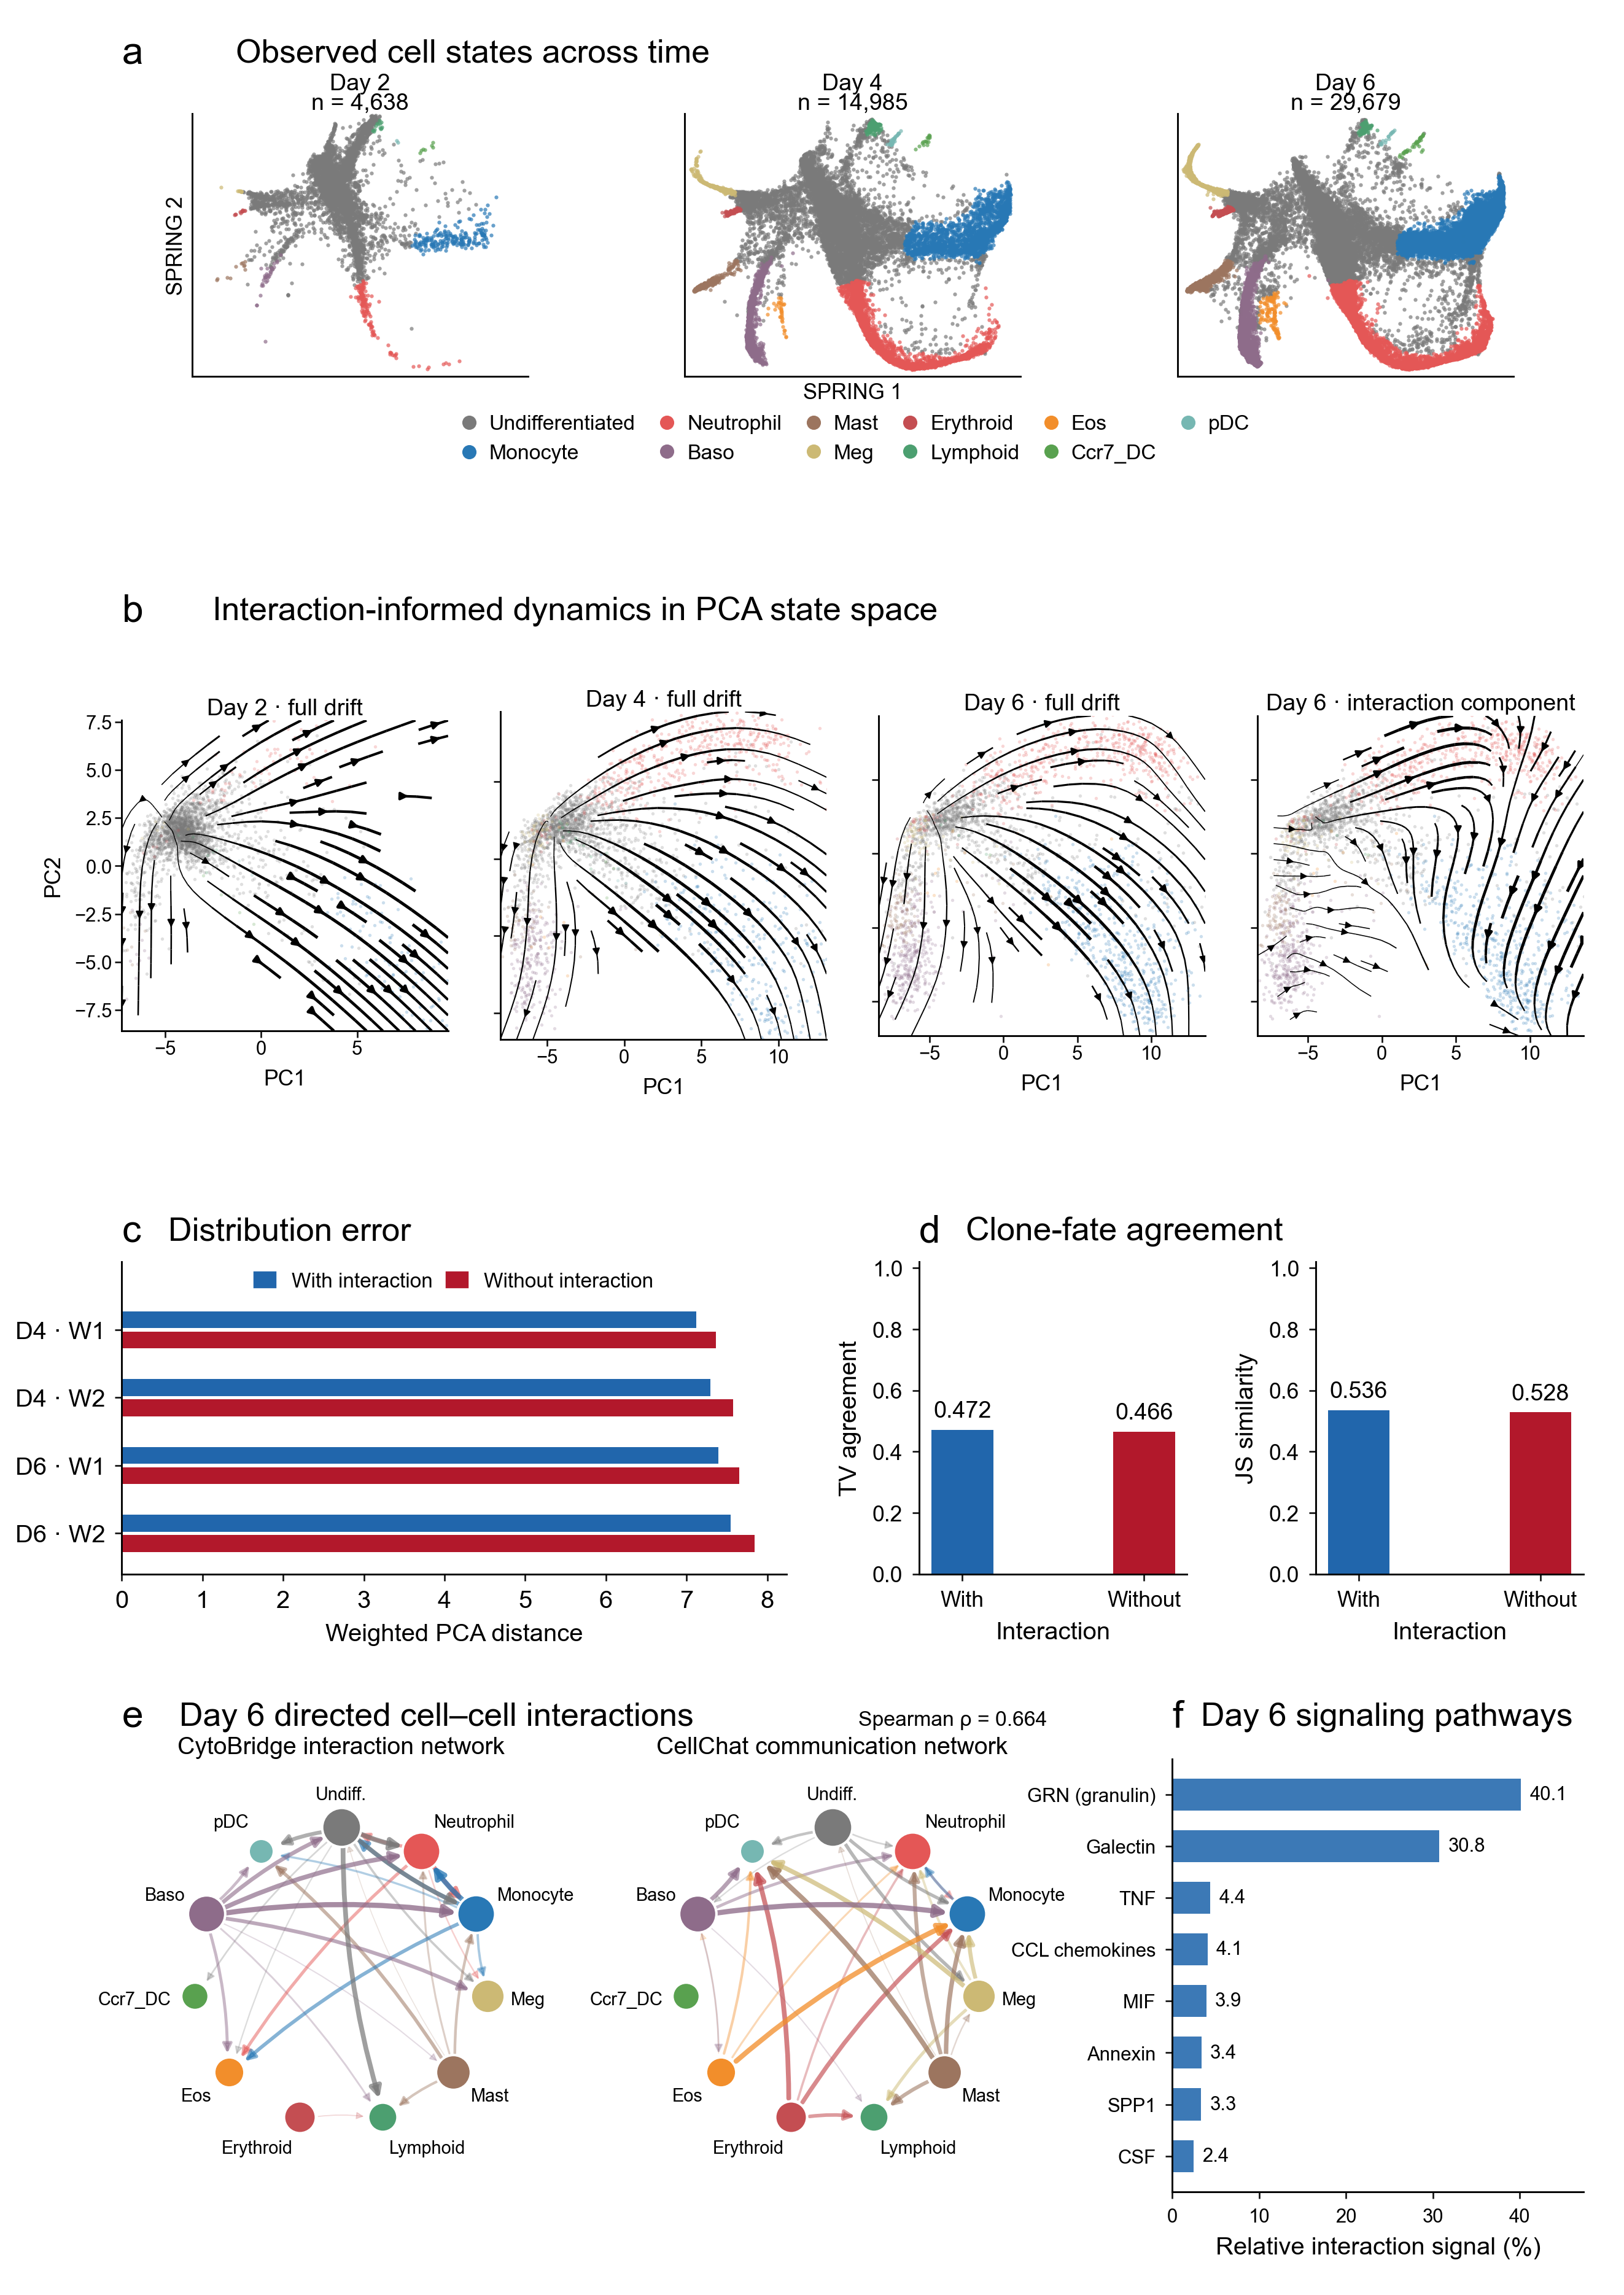

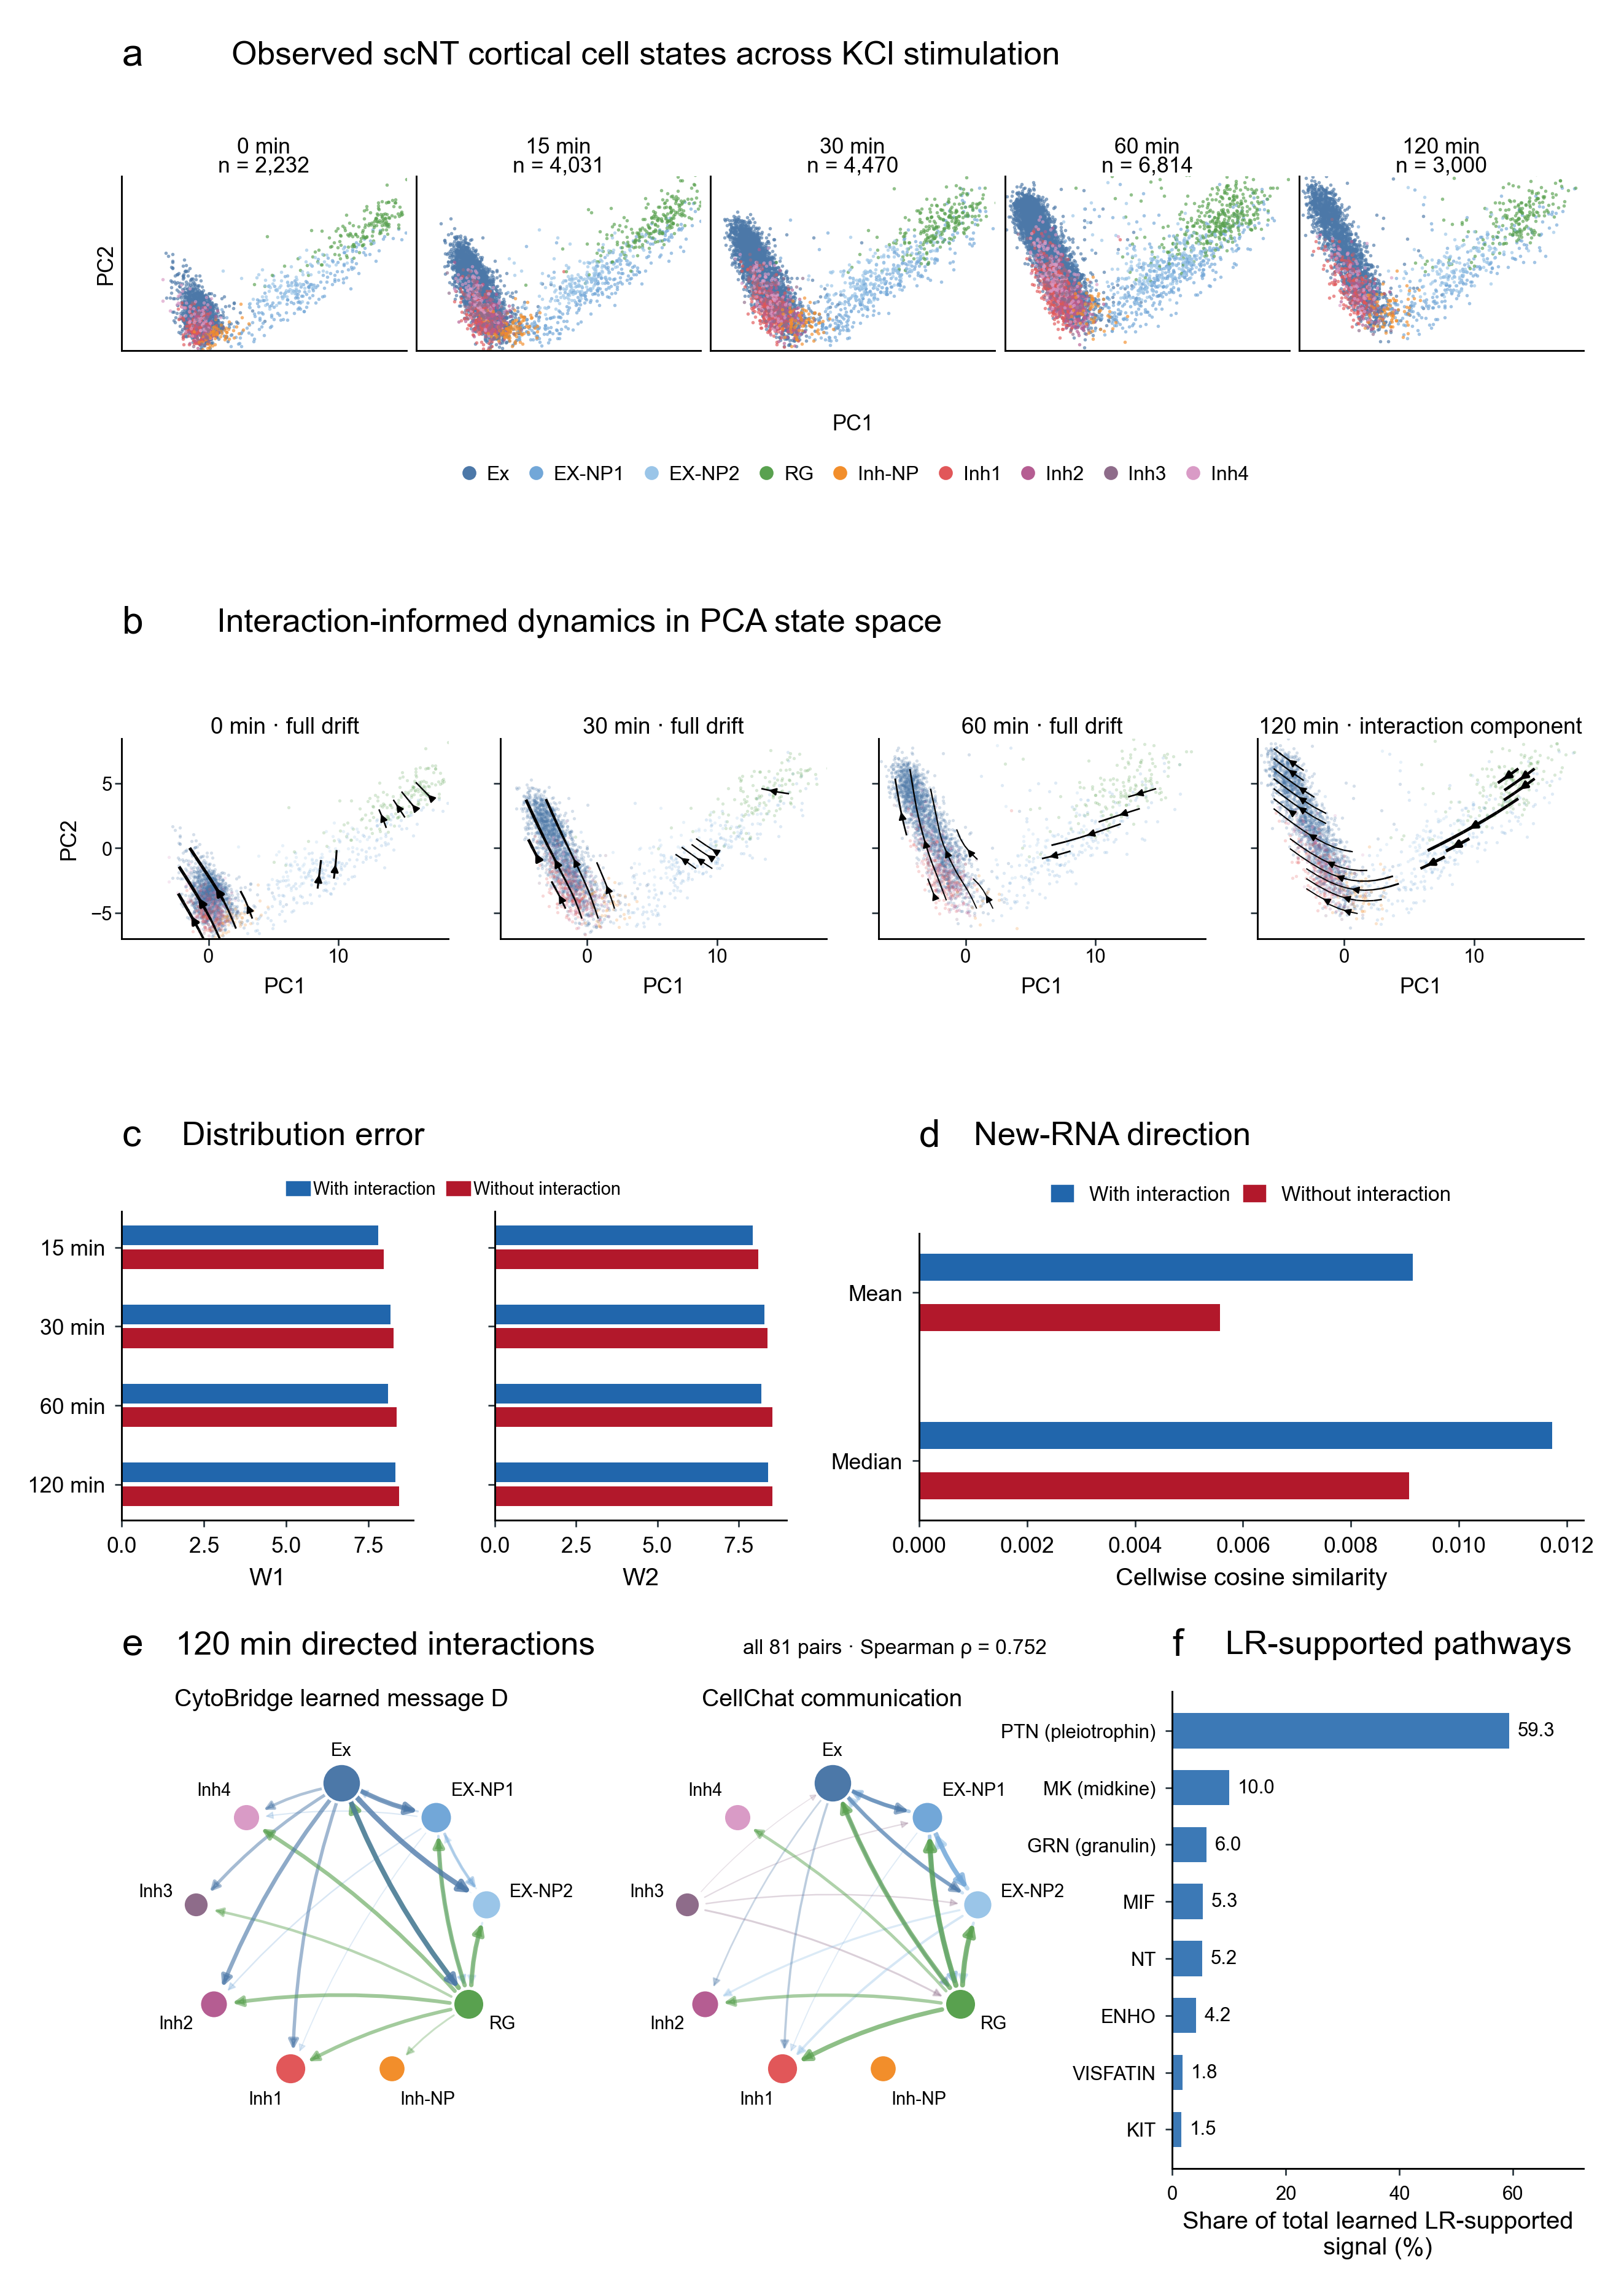

In [5]:
from reproduction.paper_figures import draw_supplementary
figures = draw_supplementary(
    [4, 5], output / "figures", results_dir=data.source_dir,
    data=data, panels=panels)
for name, (_, png) in figures.items():
    print(name.upper())
    display(Image(filename=str(png), width=720))